# Apertus vs Llama activation analysis (expanded)

This notebook runs a larger token-level activation analysis for **Apertus** and **Llama**.

It now:
- collects more samples/tokens,
- evaluates the requested layer set: **[4, 10, 16, 20, 24, 26, 28, 30]**,
- plots PCA projections for each layer and model,
- computes multiple separation metrics (silhouette, centroid distances, Fisher ratio, linear probe AUC/ACC, KMeans ARI/NMI).

In [1]:
import importlib
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import disable_progress_bar

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import utils.activation_analysis as activation_analysis
activation_analysis = importlib.reload(activation_analysis)

CollectionSpec = activation_analysis.CollectionSpec
DatasetSpec = activation_analysis.DatasetSpec
build_metrics_table = activation_analysis.build_metrics_table
build_metrics_table_for_ratio = activation_analysis.build_metrics_table_for_ratio
build_pca_plot_frame = activation_analysis.build_pca_plot_frame
collect_multilayer_activations_for_model = activation_analysis.collect_multilayer_activations_for_model
equalize_sweep_results_for_fair_comparison = activation_analysis.equalize_sweep_results_for_fair_comparison
summarize_collection_counts = activation_analysis.summarize_collection_counts

disable_progress_bar()
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

TARGET_LAYERS = [4, 10, 16, 20, 24, 26, 28, 30]

MAX_TOKENS_PER_LABEL = 30000
MAX_COMPLETION_LENGTH = 1536
MAX_SAMPLES = 3000
FAIR_POS_NEG_RATIO = 1.0

DATASET_SPLIT = "test"

MODEL_SPECS = {
    "apertus": {
        "subset": "Apertus_8B_Instruct_2509",
        "model_name": "swiss-ai/Apertus-8B-Instruct-2509",
    },
    "llama": {
        "subset": "Meta_Llama_3.1_8B_Instruct",
        "model_name": "meta-llama/Meta-Llama-3.1-8B-Instruct",
    },
}

dataset_spec = DatasetSpec(
    hf_repo="tkwiecinski/longfact-test-split",
    split=DATASET_SPLIT,
    max_length=MAX_COMPLETION_LENGTH,
    max_samples=MAX_SAMPLES,
    seed=SEED,
)

collection_spec = CollectionSpec(
    layers=TARGET_LAYERS,
    max_tokens_per_label=MAX_TOKENS_PER_LABEL,
    pos_neg_ratio=FAIR_POS_NEG_RATIO,
    enforce_ratio_on_finalize=True,
)

{
    "target_layers": TARGET_LAYERS,
    "max_samples": dataset_spec.max_samples,
    "max_tokens_per_label": collection_spec.max_tokens_per_label,
    "fair_pos_neg_ratio": FAIR_POS_NEG_RATIO,
}

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


{'target_layers': [4, 10, 16, 20, 24, 26, 28, 30],
 'max_samples': 3000,
 'max_tokens_per_label': 30000,
 'fair_pos_neg_ratio': 1.0}

In [2]:
sweep_results = {}
for model_key in ["apertus", "llama"]:
    spec = MODEL_SPECS[model_key]
    sweep_results[model_key] = collect_multilayer_activations_for_model(
        model_key=model_key,
        model_name=spec["model_name"],
        subset=spec["subset"],
        dataset_spec=dataset_spec,
        collection_spec=collection_spec,
    )

print("Collection finished.")


Loading model/tokenizer: apertus (swiss-ai/Apertus-8B-Instruct-2509)


`torch_dtype` is deprecated! Use `dtype` instead!
CUDA-fused xIELU not available (No module named 'xielu') – falling back to a Python version.
For CUDA xIELU (experimental), `pip install git+https://github.com/nickjbrowning/XIELU`
Loading checkpoint shards: 100%|██████████| 4/4 [08:10<00:00, 122.63s/it]


Shuffling and truncating dataset to 3000 / 1993 samples
Loading dataset: tkwiecinski/longfact-test-split | Apertus_8B_Instruct_2509 | test


Processing items (activation_Apertus_8B_Instruct_2509):  31%|███       | 614/1993 [00:06<00:17, 80.28it/s] 

Repeating position_slice search on all tokens after failing to find span 'United States' in input_ids[cur_idx:]: ' Treaty of Versailles, which reflected some Enlig...


...

Processing items (activation_Meta_Llama_3.1_8B_Instruct):  99%|█████████▉| 1984/1996 [00:33<00:00, 57.29it/s]

Repeating position_slice search on all tokens after failing to find span '4 clinical trials involving 241 patients' in input_ids[cur_idx:]: ' Oncolytic virus immunotherapy for prostate cance...


Processing items (activation_Meta_Llama_3.1_8B_Instruct): 100%|██████████| 1996/1996 [00:33<00:00, 59.30it/s]


Dataset activation_Meta_Llama_3.1_8B_Instruct stats:
	- Number of added spans: 22659
	- Number of skipped spans: 185 / 22844
	- Total number of items: 1996
Dataset size (Meta_Llama_3.1_8B_Instruct): 1996


llama layer 4: 30000 hallucinated / 30000 supported
llama layer 10: 30000 hallucinated / 30000 supported
llama layer 16: 30000 hallucinated / 30000 supported
llama layer 20: 30000 hallucinated / 30000 supported
llama layer 24: 30000 hallucinated / 30000 supported
llama layer 26: 30000 hallucinated / 30000 supported
llama layer 28: 30000 hallucinated / 30000 supported
llama layer 30: 30000 hallucinated / 30000 supported
Collection finished.


In [3]:
# Raw counts after collection
raw_counts_df = summarize_collection_counts(sweep_results, TARGET_LAYERS)

# Fair view: equal per-layer counts across models using identical class ratio
fair_sweep_results = equalize_sweep_results_for_fair_comparison(
    sweep_results,
    TARGET_LAYERS,
    pos_neg_ratio=FAIR_POS_NEG_RATIO,
    seed=SEED,
)
counts_df = summarize_collection_counts(fair_sweep_results, TARGET_LAYERS)

print("Raw counts (before cross-model equalization):")
display(raw_counts_df)
print("\nFair counts (after cross-model equalization):")
counts_df

Raw counts (before cross-model equalization):


,model,layer,hallucinated_tokens,supported_tokens,hidden_dim
0,apertus,4,30000,30000,4096
1,apertus,10,30000,30000,4096
2,apertus,16,30000,30000,4096
3,apertus,20,30000,30000,4096
4,apertus,24,30000,30000,4096
5,apertus,26,30000,30000,4096
6,apertus,28,30000,30000,4096
7,apertus,30,30000,30000,4096
8,llama,4,30000,30000,4096
9,llama,10,30000,30000,4096



Fair counts (after cross-model equalization):


,model,layer,hallucinated_tokens,supported_tokens,hidden_dim
0,apertus,4,30000,30000,4096
1,apertus,10,30000,30000,4096
2,apertus,16,30000,30000,4096
3,apertus,20,30000,30000,4096
4,apertus,24,30000,30000,4096
5,apertus,26,30000,30000,4096
6,apertus,28,30000,30000,4096
7,apertus,30,30000,30000,4096
8,llama,4,30000,30000,4096
9,llama,10,30000,30000,4096


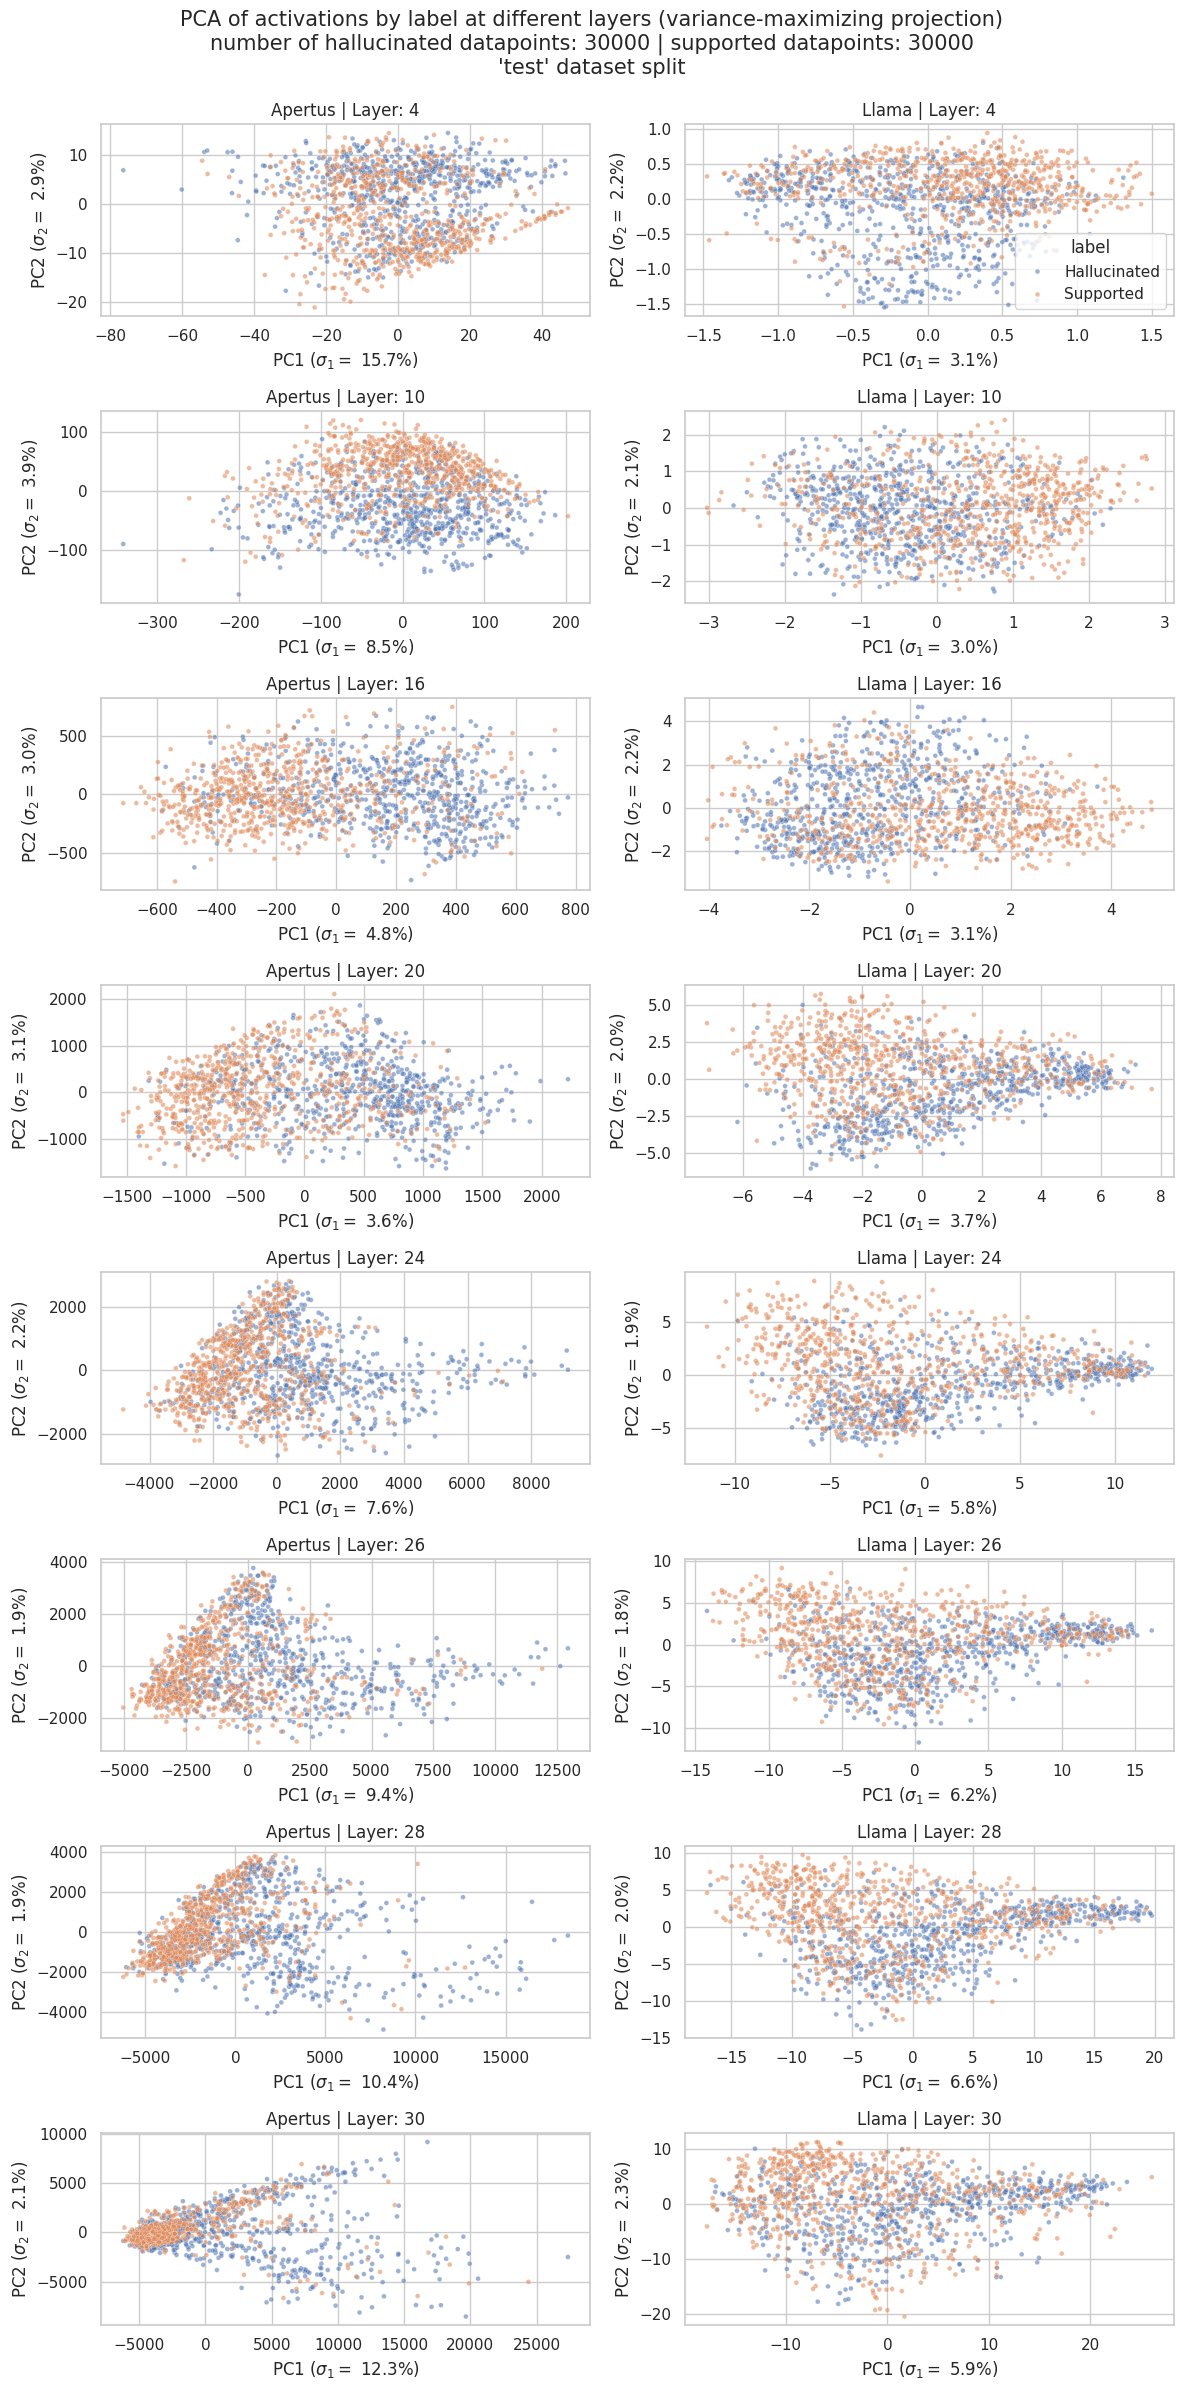

In [4]:
pca_df = build_pca_plot_frame(
    fair_sweep_results,
    TARGET_LAYERS,
    max_points_per_label=700,
    seed=SEED,
)

if pca_df.empty:
    print("No PCA data available.")
else:
    n_rows = len(TARGET_LAYERS)
    fig, axes = plt.subplots(n_rows, 2, figsize=(12, 3.0 * n_rows))
    fig.suptitle(
        f"PCA of activations by label at different layers (variance-maximizing projection)\n" +
        f"number of hallucinated datapoints: {counts_df['hallucinated_tokens'].iloc[0]} | supported datapoints: {counts_df['supported_tokens'].iloc[0]}\n" +
        f"'{DATASET_SPLIT}' dataset split",
        fontsize=15,
        y=0.995,
    )

    for row_idx, layer in enumerate(TARGET_LAYERS):
        for col_idx, model_key in enumerate(["apertus", "llama"]):
            ax = axes[row_idx, col_idx]
            cur = pca_df[(pca_df["layer"] == layer) & (pca_df["model"] == model_key)]

            count_row = counts_df[(counts_df["layer"] == layer) & (counts_df["model"] == model_key)]

            if cur.empty:
                ax.set_title(f"{model_key.title()} | Layer: {layer} (no PCA data)")
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            sns.scatterplot(
                data=cur,
                x="pc1",
                y="pc2",
                hue="label",
                alpha=0.55,
                s=12,
                ax=ax,
                legend=(row_idx == 0 and col_idx == 1),
            )
            v1 = cur["pc1_var"].iloc[0]
            v2 = cur["pc2_var"].iloc[0]
            ax.set_title(f"{model_key.title()} | Layer: {layer}")
            ax.set_xlabel(f"PC1 ($\sigma_1=$ {v1:.1%})")
            ax.set_ylabel(f"PC2 ($\sigma_2=$ {v2:.1%})")

            if not (row_idx == 0 and col_idx == 1):
                leg = ax.get_legend()
                if leg is not None:
                    leg.remove()

    fig.tight_layout(rect=[0, 0, 1, 1])
    plt.show()

In [5]:
metrics_df = build_metrics_table(fair_sweep_results, TARGET_LAYERS, seed=SEED)
metrics_df

,model,layer,n_pos,n_neg,pos_neg_ratio_used,silhouette_pca10,centroid_l2_hidden,centroid_cosine_dist_hidden,fisher_ratio_hidden,linear_probe_auc_pca20,linear_probe_acc_pca20,kmeans_ari_pca20,kmeans_nmi_pca20
0,apertus,4,30000.0,30000.0,1.0,0.027785,6.960910,0.001167,51.634626,0.847235,0.773056,0.010044,0.007270
1,apertus,10,30000.0,30000.0,1.0,0.050628,60.554287,0.007587,101.555378,0.883875,0.804444,0.004038,0.003126
2,apertus,16,30000.0,30000.0,1.0,0.068458,359.963135,0.017713,124.007178,0.882948,0.810389,0.215933,0.164322
3,apertus,20,30000.0,30000.0,1.0,0.062924,807.219238,0.015108,90.454609,0.882949,0.805889,0.182714,0.136818
4,apertus,24,30000.0,30000.0,1.0,0.075170,1957.342163,0.008300,133.135047,0.867817,0.794167,0.081575,0.091620
5,apertus,26,30000.0,30000.0,1.0,0.077452,2513.031738,0.007442,141.317170,0.864106,0.788889,0.076220,0.086207
6,apertus,28,30000.0,30000.0,1.0,0.071655,3102.258301,0.006754,138.026321,0.864774,0.790500,0.097978,0.098888
7,apertus,30,30000.0,30000.0,1.0,0.079076,4566.378418,0.011487,169.635740,0.856180,0.784000,0.074736,0.079042
8,llama,4,30000.0,30000.0,1.0,0.039833,0.550055,0.041147,52.189599,0.860388,0.780222,0.029066,0.021836
9,llama,10,30000.0,30000.0,1.0,0.046509,1.116571,0.049757,61.441534,0.884164,0.810611,0.152893,0.114467


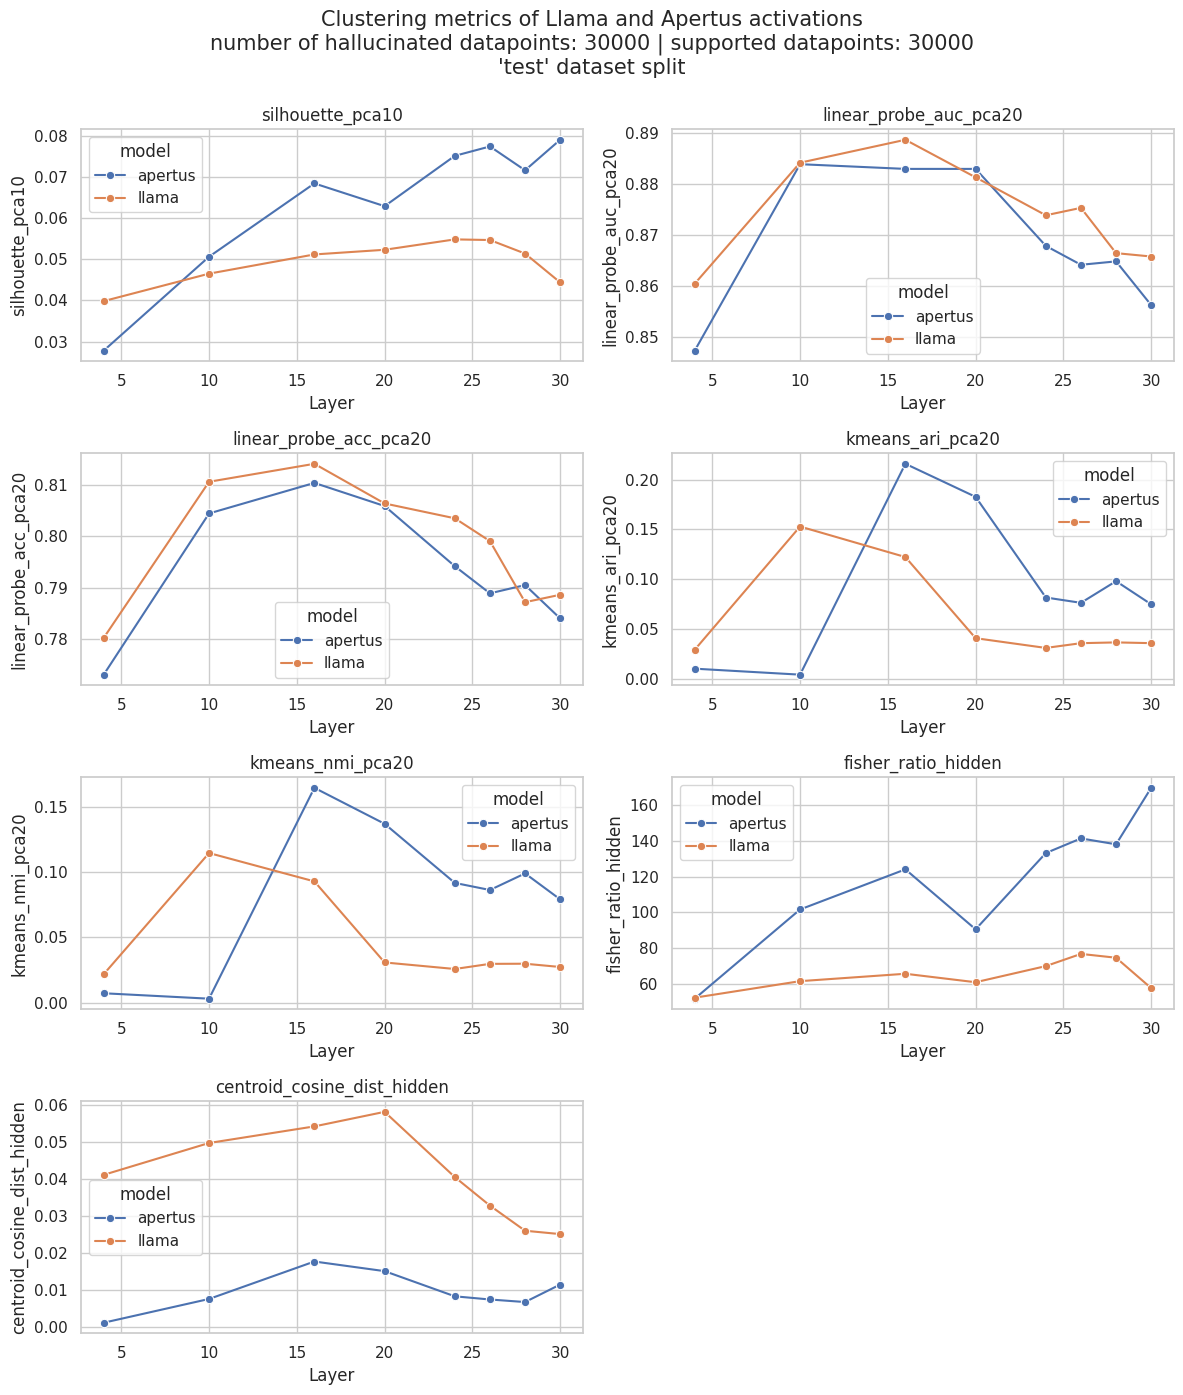

In [6]:
metric_cols = [
    "silhouette_pca10",
    "linear_probe_auc_pca20",
    "linear_probe_acc_pca20",
    "kmeans_ari_pca20",
    "kmeans_nmi_pca20",
    "fisher_ratio_hidden",
    "centroid_cosine_dist_hidden",
]
fig, axes = plt.subplots(4, 2, figsize=(12, 14))

fig.suptitle(
        f"Clustering metrics of Llama and Apertus activations\n" +
        f"number of hallucinated datapoints: {counts_df['hallucinated_tokens'].iloc[0]} | supported datapoints: {counts_df['supported_tokens'].iloc[0]}" +
        f"\n'{DATASET_SPLIT}' dataset split",

        fontsize=15,
        y=0.995,
    )
axes = axes.flatten()

for ax, metric in zip(axes, metric_cols):
    sns.lineplot(
        data=metrics_df,
        x="layer",
        y=metric,
        hue="model",
        marker="o",
        ax=ax,
    )
    ax.set_title(metric)
    ax.set_xlabel("Layer")

for i in range(len(metric_cols), len(axes)):
    axes[i].axis("off")

fig.tight_layout(rect=[0, 0, 1, 1])
plt.show()

In [7]:
best_by_metric = {}
for metric in [
    "silhouette_pca10",
    "linear_probe_auc_pca20",
    "kmeans_ari_pca20",
    "fisher_ratio_hidden",
]:
    idx = metrics_df.groupby("model")[metric].idxmax()
    best_by_metric[metric] = metrics_df.loc[idx, ["model", "layer", metric]].reset_index(drop=True)

best_by_metric["silhouette_pca10"]

,model,layer,silhouette_pca10
0,apertus,30,0.079076
1,llama,24,0.054845


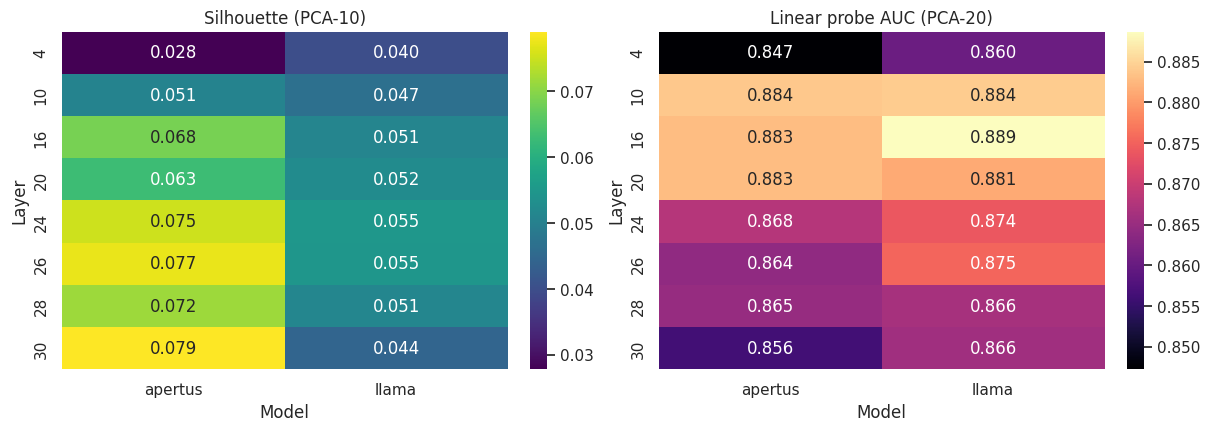

In [8]:
pivot_sil = metrics_df.pivot(index="layer", columns="model", values="silhouette_pca10")
pivot_auc = metrics_df.pivot(index="layer", columns="model", values="linear_probe_auc_pca20")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

sns.heatmap(pivot_sil, annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_title("Silhouette (PCA-10)")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Layer")

sns.heatmap(pivot_auc, annot=True, fmt=".3f", cmap="magma", ax=axes[1])
axes[1].set_title("Linear probe AUC (PCA-20)")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Layer")

plt.show()

In [9]:
# Compact summary of the main results for interpretation
display(metrics_df.sort_values(["model", "layer"]).reset_index(drop=True))

summary_metrics = [
    "silhouette_pca10",
    "linear_probe_auc_pca20",
    "linear_probe_acc_pca20",
    "kmeans_ari_pca20",
    "kmeans_nmi_pca20",
    "fisher_ratio_hidden",
    "centroid_cosine_dist_hidden",
]

# Best layer per model for each metric
best_rows = []
for metric in summary_metrics:
    idx = metrics_df.groupby("model")[metric].idxmax()
    cur = metrics_df.loc[idx, ["model", "layer", metric]].copy()
    cur["metric"] = metric
    cur = cur[["metric", "model", "layer", metric]]
    best_rows.append(cur)

best_layers_df = pd.concat(best_rows, ignore_index=True)
print("Best layer by metric and model:")
display(best_layers_df)

# Model-level averages across all layers
avg_by_model = metrics_df.groupby("model")[summary_metrics].mean(numeric_only=True)
print("Average metric values across evaluated layers:")
display(avg_by_model)

# Apertus - Llama difference (positive means Apertus higher on average)
if {"apertus", "llama"}.issubset(set(avg_by_model.index)):
    delta = (avg_by_model.loc["apertus"] - avg_by_model.loc["llama"]).to_frame(name="apertus_minus_llama")
    print("Average delta across layers (Apertus - Llama):")
    display(delta.sort_values("apertus_minus_llama", ascending=False))

# Count table sanity check
print("Token counts after fairness equalization:")
display(counts_df.sort_values(["layer", "model"]).reset_index(drop=True))

,model,layer,n_pos,n_neg,pos_neg_ratio_used,silhouette_pca10,centroid_l2_hidden,centroid_cosine_dist_hidden,fisher_ratio_hidden,linear_probe_auc_pca20,linear_probe_acc_pca20,kmeans_ari_pca20,kmeans_nmi_pca20
0,apertus,4,30000.0,30000.0,1.0,0.027785,6.960910,0.001167,51.634626,0.847235,0.773056,0.010044,0.007270
1,apertus,10,30000.0,30000.0,1.0,0.050628,60.554287,0.007587,101.555378,0.883875,0.804444,0.004038,0.003126
2,apertus,16,30000.0,30000.0,1.0,0.068458,359.963135,0.017713,124.007178,0.882948,0.810389,0.215933,0.164322
3,apertus,20,30000.0,30000.0,1.0,0.062924,807.219238,0.015108,90.454609,0.882949,0.805889,0.182714,0.136818
4,apertus,24,30000.0,30000.0,1.0,0.075170,1957.342163,0.008300,133.135047,0.867817,0.794167,0.081575,0.091620
5,apertus,26,30000.0,30000.0,1.0,0.077452,2513.031738,0.007442,141.317170,0.864106,0.788889,0.076220,0.086207
6,apertus,28,30000.0,30000.0,1.0,0.071655,3102.258301,0.006754,138.026321,0.864774,0.790500,0.097978,0.098888
7,apertus,30,30000.0,30000.0,1.0,0.079076,4566.378418,0.011487,169.635740,0.856180,0.784000,0.074736,0.079042
8,llama,4,30000.0,30000.0,1.0,0.039833,0.550055,0.041147,52.189599,0.860388,0.780222,0.029066,0.021836
9,llama,10,30000.0,30000.0,1.0,0.046509,1.116571,0.049757,61.441534,0.884164,0.810611,0.152893,0.114467


Best layer by metric and model:


,metric,model,layer,silhouette_pca10,linear_probe_auc_pca20,linear_probe_acc_pca20,kmeans_ari_pca20,kmeans_nmi_pca20,fisher_ratio_hidden,centroid_cosine_dist_hidden
0,silhouette_pca10,apertus,30,0.079076,NaN,NaN,NaN,NaN,NaN,NaN
1,silhouette_pca10,llama,24,0.054845,NaN,NaN,NaN,NaN,NaN,NaN
2,linear_probe_auc_pca20,apertus,10,NaN,0.883875,NaN,NaN,NaN,NaN,NaN
3,linear_probe_auc_pca20,llama,16,NaN,0.888672,NaN,NaN,NaN,NaN,NaN
4,linear_probe_acc_pca20,apertus,16,NaN,NaN,0.810389,NaN,NaN,NaN,NaN
5,linear_probe_acc_pca20,llama,16,NaN,NaN,0.814111,NaN,NaN,NaN,NaN
6,kmeans_ari_pca20,apertus,16,NaN,NaN,NaN,0.215933,NaN,NaN,NaN
7,kmeans_ari_pca20,llama,10,NaN,NaN,NaN,0.152893,NaN,NaN,NaN
8,kmeans_nmi_pca20,apertus,16,NaN,NaN,NaN,NaN,0.164322,NaN,NaN
9,kmeans_nmi_pca20,llama,10,NaN,NaN,NaN,NaN,0.114467,NaN,NaN


Average metric values across evaluated layers:


,silhouette_pca10,linear_probe_auc_pca20,linear_probe_acc_pca20,kmeans_ari_pca20,kmeans_nmi_pca20,fisher_ratio_hidden,centroid_cosine_dist_hidden
model,,,,,,,
apertus,0.064144,0.868735,0.793917,0.092905,0.083412,118.720759,0.009445
llama,0.049394,0.874471,0.798708,0.060448,0.046587,64.838808,0.040980


Average delta across layers (Apertus - Llama):


,apertus_minus_llama
fisher_ratio_hidden,53.881951
kmeans_nmi_pca20,0.036825
kmeans_ari_pca20,0.032456
silhouette_pca10,0.014749
linear_probe_acc_pca20,-0.004792
linear_probe_auc_pca20,-0.005735
centroid_cosine_dist_hidden,-0.031535


Token counts after fairness equalization:


,model,layer,hallucinated_tokens,supported_tokens,hidden_dim
0,apertus,4,30000,30000,4096
1,llama,4,30000,30000,4096
2,apertus,10,30000,30000,4096
3,llama,10,30000,30000,4096
4,apertus,16,30000,30000,4096
5,llama,16,30000,30000,4096
6,apertus,20,30000,30000,4096
7,llama,20,30000,30000,4096
8,apertus,24,30000,30000,4096
9,llama,24,30000,30000,4096


In [10]:
# Per-layer deltas (Apertus - Llama) for quick trend reading
for metric in [
    "silhouette_pca10",
    "linear_probe_auc_pca20",
    "linear_probe_acc_pca20",
    "kmeans_ari_pca20",
    "kmeans_nmi_pca20",
    "fisher_ratio_hidden",
    "centroid_cosine_dist_hidden",
]:
    pivot = metrics_df.pivot(index="layer", columns="model", values=metric).sort_index()
    if {"apertus", "llama"}.issubset(pivot.columns):
        pivot["delta_apertus_minus_llama"] = pivot["apertus"] - pivot["llama"]
    print(f"\n=== {metric} ===")
    display(pivot.round(6))


=== silhouette_pca10 ===


model,apertus,llama,delta_apertus_minus_llama
layer,,,
4,0.027785,0.039833,-0.012048
10,0.050628,0.046509,0.004119
16,0.068458,0.051183,0.017275
20,0.062924,0.052317,0.010607
24,0.075170,0.054845,0.020326
26,0.077452,0.054691,0.022762
28,0.071655,0.051397,0.020258
30,0.079076,0.044381,0.034695



=== linear_probe_auc_pca20 ===


model,apertus,llama,delta_apertus_minus_llama
layer,,,
4,0.847235,0.860388,-0.013153
10,0.883875,0.884164,-0.000289
16,0.882948,0.888672,-0.005724
20,0.882949,0.881289,0.001659
24,0.867817,0.873833,-0.006016
26,0.864106,0.875293,-0.011187
28,0.864774,0.866394,-0.001620
30,0.856180,0.865732,-0.009552



=== linear_probe_acc_pca20 ===


...

model,apertus,llama,delta_apertus_minus_llama
layer,,,
4,0.007270,0.021836,-0.014566
10,0.003126,0.114467,-0.111341
16,0.164322,0.092787,0.071536
20,0.136818,0.030825,0.105993
24,0.091620,0.025822,0.065799
26,0.086207,0.029749,0.056457
28,0.098888,0.029853,0.069035
30,0.079042,0.027357,0.051685



=== fisher_ratio_hidden ===


model,apertus,llama,delta_apertus_minus_llama
layer,,,
4,51.634626,52.189599,-0.554973
10,101.555378,61.441534,40.113845
16,124.007178,65.578954,58.428224
20,90.454609,60.838476,29.616133
24,133.135047,69.869934,63.265113
26,141.317170,76.684798,64.632372
28,138.026321,74.556515,63.469806
30,169.635740,57.550653,112.085087



=== centroid_cosine_dist_hidden ===


model,apertus,llama,delta_apertus_minus_llama
layer,,,
4,0.001167,0.041147,-0.039980
10,0.007587,0.049757,-0.042170
16,0.017713,0.054243,-0.036531
20,0.015108,0.058177,-0.043068
24,0.008300,0.040536,-0.032235
26,0.007442,0.032821,-0.025379
28,0.006754,0.026035,-0.019281
30,0.011487,0.025124,-0.013637


In [11]:

rows = []
for model_key, model_res in sweep_results.items():
    for layer in TARGET_LAYERS:
        pre_pos = len(model_res["per_layer"][layer]["positive"])
        pre_neg = len(model_res["per_layer"][layer]["negative"])
        post_pos = len(fair_sweep_results[model_key]["per_layer"][layer]["positive"])
        post_neg = len(fair_sweep_results[model_key]["per_layer"][layer]["negative"])
        rows.append({
            "model": model_key,
            "layer": layer,
            "pre_hallucinated": pre_pos,
            "pre_supported": pre_neg,
            "post_hallucinated": post_pos,
            "post_supported": post_neg,
        })

debug_counts = pd.DataFrame(rows).sort_values(["model", "layer"]).reset_index(drop=True)
display(debug_counts)

print("\nMin pre_hallucinated by model:")
display(debug_counts.groupby("model")["pre_hallucinated"].min())

print("\nMin pre_supported by model:")
display(debug_counts.groupby("model")["pre_supported"].min())

print("\nCurrent collection settings:")
print({
    "MAX_TOKENS_PER_LABEL": MAX_TOKENS_PER_LABEL,
    "FAIR_POS_NEG_RATIO": FAIR_POS_NEG_RATIO,
    "MAX_SAMPLES": MAX_SAMPLES,
    "MAX_COMPLETION_LENGTH": MAX_COMPLETION_LENGTH,
})

,model,layer,pre_hallucinated,pre_supported,post_hallucinated,post_supported
0,apertus,4,30000,30000,30000,30000
1,apertus,10,30000,30000,30000,30000
2,apertus,16,30000,30000,30000,30000
3,apertus,20,30000,30000,30000,30000
4,apertus,24,30000,30000,30000,30000
5,apertus,26,30000,30000,30000,30000
6,apertus,28,30000,30000,30000,30000
7,apertus,30,30000,30000,30000,30000
8,llama,4,30000,30000,30000,30000
9,llama,10,30000,30000,30000,30000



Min pre_hallucinated by model:


model
apertus    30000
llama      30000
Name: pre_hallucinated, dtype: int64


Min pre_supported by model:


model
apertus    30000
llama      30000
Name: pre_supported, dtype: int64


Current collection settings:
{'MAX_TOKENS_PER_LABEL': 30000, 'FAIR_POS_NEG_RATIO': 1.0, 'MAX_SAMPLES': 3000, 'MAX_COMPLETION_LENGTH': 1536}
